# Power Market Forecasting & BESS Arbitrage Simulation

## Project objective
This project analyses German/Luxembourg day-ahead electricity prices from 2022–2025 and connects market analysis with machine learning and a simplified battery arbitrage simulation.

The workflow is:

1. Clean and validate SMARD market data.
2. Analyse price behaviour, negative-price periods and renewable generation.
3. Build a 24-hour-ahead electricity-price forecasting model.
4. Compare persistence, Linear Regression, Random Forest and XGBoost.
5. Evaluate the selected model on a held-out 2025 test period.
6. Use the 2025 forecasts in a simplified BESS arbitrage simulation.

**Data source:** SMARD, Bundesnetzagentur (`https://www.smard.de`).

### Why this workflow was chosen
Electricity prices are a **time-series problem**, so the notebook moves from data quality → market understanding → forecasting → economic application. This order matters: a forecasting model is only meaningful after timestamps are reliable and the main market patterns are understood. The final BESS section then tests whether the forecasts can support a simple battery-arbitrage decision rule.


### Import libraries
`pandas` handles tables and time-series data, `numpy` handles numerical calculations, and `matplotlib` is used for visualisation.

**Why these libraries?** They cover the core needs of this project without adding unnecessary complexity: `pandas` for hourly market tables and timestamps, `numpy` for numerical calculations, and `matplotlib` for charts. More specialised modelling libraries are imported later only when they are needed.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and inspect day-ahead price data

The SMARD day-ahead price data is split into two CSV files covering different time periods.

`sep=";"` is used because the files are semicolon-separated, and `na_values="-"` converts SMARD's missing-value marker into `NaN`.

We first load the files and look at a few rows before deciding which columns to keep.


In [2]:
price_2022_2023 = pd.read_csv("Day-ahead_prices_202201010000_202401010000_Hour.csv", sep=";", na_values="-")

In [3]:
price_2022_2023.head()

,Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
0,"Jan 1, 2022 12:00 AM","Jan 1, 2022 1:00 AM",50.05,78.44,82.02,50.05,46.60,89.06,124.70,132.89,61.84,59.03,46.60,119.97,50.05,NaN,170.28,61.84,61.84
1,"Jan 1, 2022 1:00 AM","Jan 1, 2022 2:00 AM",41.33,69.75,67.07,41.33,41.33,78.48,124.70,129.30,51.44,49.37,41.33,101.54,41.33,NaN,155.72,51.44,41.33
2,"Jan 1, 2022 2:00 AM","Jan 1, 2022 3:00 AM",43.22,68.04,75.11,43.22,42.18,85.16,134.00,132.08,55.91,43.22,42.18,52.13,43.22,NaN,147.09,55.91,43.22
3,"Jan 1, 2022 3:00 AM","Jan 1, 2022 4:00 AM",45.46,51.27,50.91,45.46,44.37,50.00,58.80,111.44,46.94,45.46,44.37,20.78,45.46,NaN,91.00,46.94,45.46
4,"Jan 1, 2022 4:00 AM","Jan 1, 2022 5:00 AM",37.67,42.46,37.67,37.67,37.67,37.67,37.67,112.35,37.67,37.67,37.67,15.66,37.67,NaN,104.00,37.67,37.67


In [4]:
price_2024_2025 = pd.read_csv("Day-ahead_prices_202401010000_202601010000_Hour.csv", sep=";", na_values="-")

In [5]:
price_2024_2025.head()

,Start date,End date,Germany/Luxembourg [€/MWh] Calculated resolutions,∅ DE/LU neighbours [€/MWh] Calculated resolutions,Belgium [€/MWh] Calculated resolutions,Denmark 1 [€/MWh] Calculated resolutions,Denmark 2 [€/MWh] Calculated resolutions,France [€/MWh] Calculated resolutions,Netherlands [€/MWh] Calculated resolutions,Norway 2 [€/MWh] Calculated resolutions,Austria [€/MWh] Calculated resolutions,Poland [€/MWh] Calculated resolutions,Sweden 4 [€/MWh] Calculated resolutions,Switzerland [€/MWh] Calculated resolutions,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions
0,"Jan 1, 2024 12:00 AM","Jan 1, 2024 1:00 AM",0.10,21.15,0.10,16.99,29.13,0.10,0.10,53.79,0.10,76.69,29.56,25.97,0.10,NaN,107.09,0.10,0.10
1,"Jan 1, 2024 1:00 AM","Jan 1, 2024 2:00 AM",0.01,20.96,0.01,28.14,28.46,0.01,0.01,48.98,0.01,74.50,28.46,21.99,0.01,NaN,104.00,0.01,0.01
2,"Jan 1, 2024 2:00 AM","Jan 1, 2024 3:00 AM",0.00,17.73,0.00,26.66,26.66,0.00,0.00,27.45,0.02,73.29,26.66,14.32,0.02,NaN,100.00,0.03,0.04
3,"Jan 1, 2024 3:00 AM","Jan 1, 2024 4:00 AM",-0.01,14.59,-0.01,4.14,24.48,-0.01,-0.01,24.48,0.00,71.58,24.48,11.37,0.00,NaN,85.66,0.00,0.01
4,"Jan 1, 2024 4:00 AM","Jan 1, 2024 5:00 AM",-0.03,14.23,-0.03,-0.03,24.01,-0.03,-0.03,24.01,-0.01,73.27,24.01,11.35,-0.01,NaN,85.00,0.00,0.01


From the previews we can see the timestamp field (`Start date`) and the Germany/Luxembourg day-ahead price column. These are the two fields needed to build the basic price time series.


### Select the columns needed

From the preview above, we keep:

- `Start date` — the hour of the market observation.
- `Germany/Luxembourg [€/MWh] Calculated resolutions` — the electricity price we want to analyse and later forecast.

The remaining price-file columns are not needed for this project, so removing them keeps the working table easier to read.


In [6]:
price_col = "Germany/Luxembourg [€/MWh] Calculated resolutions"

price_1 = price_2022_2023[
    ["Start date", price_col]
].copy()

price_2 = price_2024_2025[
    ["Start date", price_col]
].copy()

### Combine and rename the price data
`pd.concat()` stacks the two time periods vertically. `ignore_index=True` creates a fresh continuous index.

The long source column names are then renamed to short, analysis-friendly names with clear units.

**Why concatenate rather than merge?** The two files contain the **same variables for different dates**, so their rows should be stacked vertically. A merge is used later when different variables—price, load and generation—need to be matched for the same hour.


In [7]:
prices = pd.concat([price_1, price_2],ignore_index=True)

prices = prices.rename(columns={"Start date": "start_time_local", price_col: "price_eur_mwh"})

### Convert the timestamp to a datetime
The original timestamp is read as text. Converting it to `datetime` allows year/month/hour extraction, time-zone handling, chronological sorting and lag creation later.

**Why convert immediately?** Time-series operations such as sorting, extracting hours, creating lags and checking hourly gaps require a real datetime type. Leaving the timestamp as text would make those operations unreliable.


In [8]:
prices["start_time_local"] = pd.to_datetime(prices["start_time_local"])

prices.head()

,start_time_local,price_eur_mwh
0,2022-01-01 00:00:00,50.05
1,2022-01-01 01:00:00,41.33
2,2022-01-01 02:00:00,43.22
3,2022-01-01 03:00:00,45.46
4,2022-01-01 04:00:00,37.67


## 2. Time-zone handling

SMARD timestamps are German local time. Daylight-saving time creates a missing clock hour in spring and a repeated clock hour in autumn.

We therefore keep a Berlin-time version for calendar features and create a UTC version for a unique continuous hourly timeline.

**Why keep both Berlin time and UTC?** Berlin local time is useful for features such as hour-of-day because market behaviour follows the local clock. UTC is used as the technical joining key because every UTC hour is unique, avoiding ambiguity during daylight-saving changes.


In [9]:
prices["timestamp_berlin"] = (prices["start_time_local"].dt.tz_localize("Europe/Berlin", ambiguous="infer"))

prices["timestamp_utc"] = (prices["timestamp_berlin"].dt.tz_convert("UTC"))

### Validate the time series
After conversion to UTC, consecutive observations should be one hour apart and UTC timestamps should not be duplicated. Local duplicates are expected around the autumn daylight-saving change.

**Why validate this before analysis?** Lag features assume that one row represents the next hour. A duplicate or missing UTC hour would shift the lags and could silently give the model the wrong historical observation.


In [10]:
time_gaps = prices["timestamp_utc"].diff().dropna()

print("Rows:", len(prices))
print("Duplicate local timestamps:", prices["start_time_local"].duplicated().sum())
print("Duplicate UTC timestamps:", prices["timestamp_utc"].duplicated().sum())
print("Non-hourly UTC gaps:", (time_gaps != pd.Timedelta(hours=1)).sum())

Rows: 35064
Duplicate local timestamps: 4
Duplicate UTC timestamps: 0
Non-hourly UTC gaps: 0


The four duplicated local timestamps are the repeated autumn daylight-saving hours. After conversion to UTC, the dataset has no duplicated UTC timestamps and no hourly gaps.

## 3. Exploratory analysis of day-ahead prices
We first create calendar variables so the price data can be grouped by year, month, hour and day.

**Why calendar variables?** Electricity demand, renewable output and human activity follow strong daily and seasonal cycles. Year, month, hour and date therefore provide natural grouping variables for understanding recurring market patterns.


In [11]:
prices["year"] = prices["timestamp_berlin"].dt.year

In [12]:
prices["month"] = prices["timestamp_berlin"].dt.month

In [13]:
prices["hour"] = prices["timestamp_berlin"].dt.hour

In [14]:
prices["date"] = prices["timestamp_berlin"].dt.date

### Yearly statistics and negative-price hours
The yearly table summarises the central tendency, extremes and volatility of electricity prices.

Negative-price observations are separated because they are economically important for renewable integration and battery arbitrage.

**Why these statistics?** Mean and median describe the typical price, minimum and maximum show extremes, and standard deviation gives a simple measure of variability. Negative prices are analysed separately because they represent an unusual market state that is especially relevant to flexible assets such as batteries.


In [15]:
yearly_stats = (
    prices.groupby("year")["price_eur_mwh"]
    .agg(["mean", "median", "min", "max", "std"])
    .round(2)
)

In [16]:
negative_prices = prices[prices["price_eur_mwh"] < 0].copy()

In [17]:
negative_by_year = (negative_prices.groupby("year").size())

In [18]:
negative_share = (len(negative_prices) / len(prices) * 100)

In [19]:
print("Negative-price hours:", len(negative_prices))
print("Share of all hours:", round(negative_share, 2), "%")
display(yearly_stats)
display(negative_by_year.to_frame("negative_price_hours"))

Negative-price hours: 1400
Share of all hours: 3.99 %


,mean,median,min,max,std
year,,,,,
2022,235.45,208.34,-19.04,871.00,142.81
2023,95.18,98.02,-500.00,524.27,47.58
2024,78.51,79.59,-135.45,936.28,52.73
2025,89.32,92.43,-250.32,583.40,52.10


,negative_price_hours
year,
2022,69
2023,301
2024,457
2025,573


### Average price by year
This chart makes the change in the overall price level across 2022–2025 easy to compare.

**Why a yearly bar chart?** A yearly average compresses thousands of hourly observations into an easy regime-level comparison. It helps reveal whether one year behaves very differently before more detailed modelling is attempted.


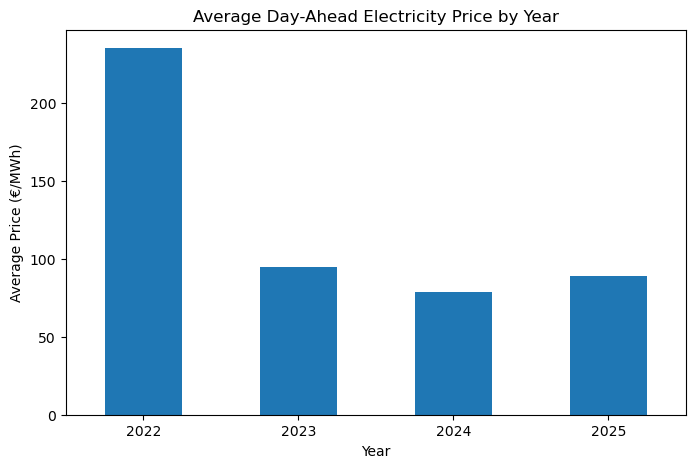

In [20]:
yearly_mean = (prices.groupby("year")["price_eur_mwh"].mean())

plt.figure(figsize=(8, 5))
yearly_mean.plot(kind="bar")
plt.title("Average Day-Ahead Electricity Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price (€/MWh)")
plt.xticks(rotation=0)
plt.show()

### Average price by hour of day
Grouping by Berlin local hour reveals the typical intraday pattern in day-ahead electricity prices.

**Why use Berlin local hour?** Charging demand, industrial activity and solar generation are tied to the local clock, not UTC. Grouping by local hour therefore gives a more interpretable intraday price profile.


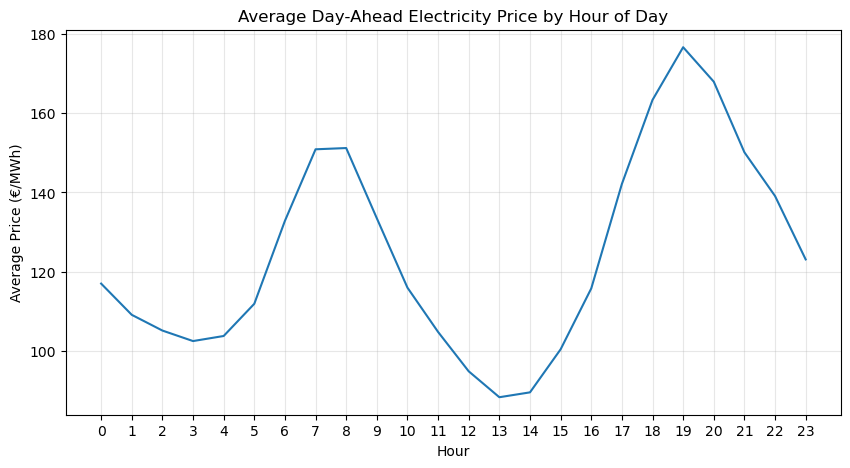

In [21]:
hourly_mean = (prices.groupby("hour")["price_eur_mwh"].mean())

plt.figure(figsize=(10, 5))
hourly_mean.plot()
plt.title("Average Day-Ahead Electricity Price by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Price (€/MWh)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

### Count negative prices by month and hour
`pd.crosstab()` creates a matrix where rows are months, columns are hours, and each value is the number of negative-price observations.

**Why a month × hour table?** Negative prices can be seasonal **and** intraday. A two-dimensional count allows both patterns to be examined at the same time instead of analysing month and hour separately.


In [22]:
negative_hour_month = pd.crosstab(negative_prices["month"], negative_prices["hour"])

### Visualise the negative-price pattern
The heatmap shows when negative prices are most concentrated across the year and across the day.

**Why a heatmap?** The matrix contains many month-hour combinations. A heatmap makes concentrations visible immediately, which is easier to interpret than scanning a large table of counts.


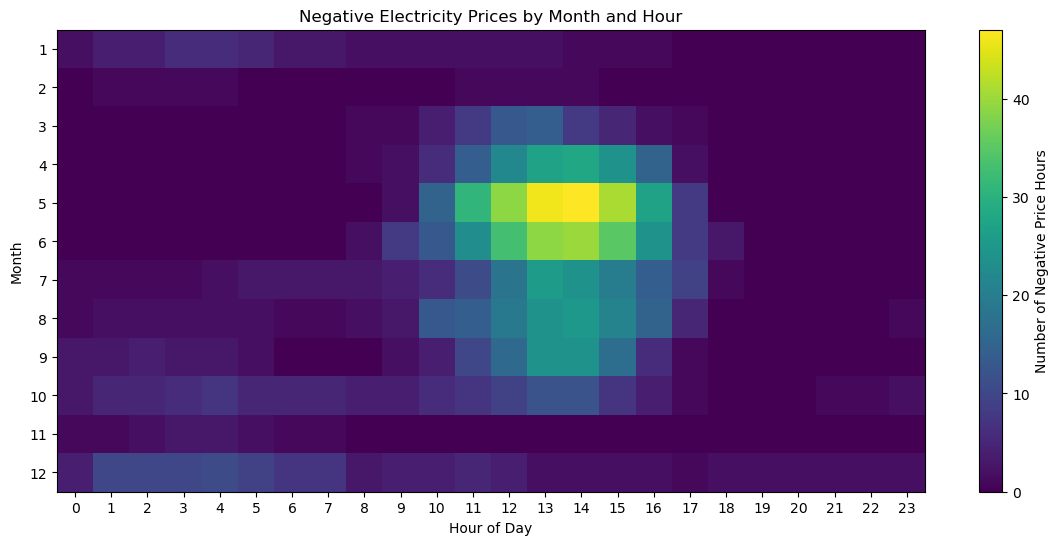

In [23]:
plt.figure(figsize=(14, 6))
plt.imshow(negative_hour_month, aspect="auto")
plt.colorbar(label="Number of Negative Price Hours")
plt.xticks(range(len(negative_hour_month.columns)), negative_hour_month.columns)
plt.yticks(range(len(negative_hour_month.index)), negative_hour_month.index)
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.title("Negative Electricity Prices by Month and Hour")
plt.show()

### Initial observations

- 2022 had a much higher average price than 2023–2025, indicating a different market regime.
- Prices show a clear intraday pattern, with lower average prices around midday and higher average prices in the evening.
- The dataset contains **1,400 negative-price hours**, about **3.99%** of all observations.
- Negative prices are concentrated particularly around late morning and afternoon in spring and summer.

These are descriptive patterns. Renewable generation and load are added next to investigate the market conditions associated with them.

### Calculate daily price spreads

For each day, we calculate the difference between the maximum and minimum electricity price.

A larger spread suggests more intraday price variation, which is interesting for battery arbitrage. However, this is only an exploratory indicator: it does not yet check whether the low-price hour occurs before the high-price hour or include battery losses and constraints.


In [24]:
daily_prices = (prices.groupby("date")["price_eur_mwh"].agg(daily_min="min", daily_max="max", daily_mean="mean"))

daily_prices["daily_spread"] = (daily_prices["daily_max"] - daily_prices["daily_min"])

daily_prices["year"] = (pd.to_datetime(daily_prices.index).year)

display(daily_prices["daily_spread"].describe().round(2))

count    1461.00
mean      130.04
std        81.86
min         4.41
25%        74.91
50%       112.58
75%       159.95
max       828.93
Name: daily_spread, dtype: float64

### Summarise the daily spreads
This gives the overall spread distribution and compares the average, median and maximum spread between years.

**Why compare spread by year?** It shows whether the economic opportunity for intraday arbitrage changes across market regimes, even when average prices fall or rise.


In [25]:
daily_spread_by_year = (daily_prices.groupby("year")["daily_spread"].agg(["mean", "median", "max"]).round(2))
display(daily_spread_by_year)

,mean,median,max
year,,,
2022,186.99,170.15,687.46
2023,97.88,89.12,594.90
2024,111.20,96.88,828.93
2025,124.13,112.46,468.99


### Plot the daily price spread over time
Large spikes indicate days with especially strong within-day price differences.

**Why plot the spread through time?** Summary statistics hide when extreme opportunities occurred. The time plot shows clustering, spikes and changing volatility that may matter to a trading strategy.


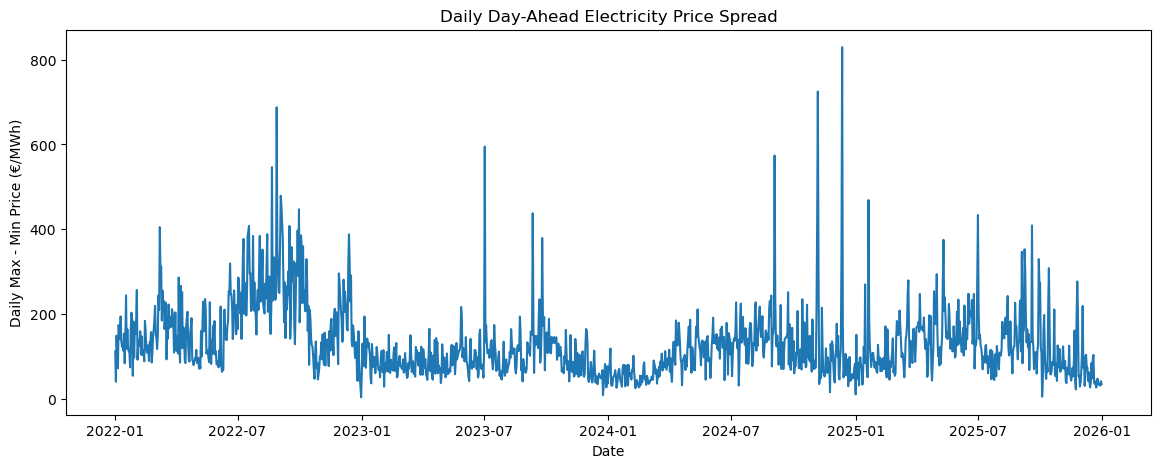

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(
    pd.to_datetime(daily_prices.index),
    daily_prices["daily_spread"]
)
plt.title("Daily Day-Ahead Electricity Price Spread")
plt.xlabel("Date")
plt.ylabel("Daily Max - Min Price (€/MWh)")
plt.show()

Daily price spreads motivate the later battery-arbitrage simulation because storage value depends on price differences within a day rather than on average price alone.

## 4. Add electricity consumption and renewable generation

Price tells us what happened in the market, but it does not explain the physical conditions behind it.

We therefore add SMARD consumption and generation data. As with the price files, we first preview the raw data and then keep only the variables that are useful for this project.

`thousands=","` allows values such as `25,602.75` to be read as numbers.


### Load and inspect electricity-consumption data

The consumption files cover the same two time periods as the price data.


In [27]:
consumption_2022_2023 = pd.read_csv(
    "Actual_consumption_202201010000_202401010000_Hour.csv",
    sep=";",
    na_values="-",
    thousands=","
)


In [28]:
consumption_2022_2023.head()


,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Jan 1, 2022 12:00 AM","Jan 1, 2022 1:00 AM",44351.25,46958.25,2607.00,12771.00
1,"Jan 1, 2022 1:00 AM","Jan 1, 2022 2:00 AM",41957.75,44621.25,2663.50,11832.75
2,"Jan 1, 2022 2:00 AM","Jan 1, 2022 3:00 AM",40888.00,43811.50,2923.50,12149.25
3,"Jan 1, 2022 3:00 AM","Jan 1, 2022 4:00 AM",39964.00,43291.75,3327.75,12465.75
4,"Jan 1, 2022 4:00 AM","Jan 1, 2022 5:00 AM",39733.50,43295.25,3561.75,13524.25


In [29]:
consumption_2024_2025 = pd.read_csv(
    "Actual_consumption_202401010000_202601010000_Hour.csv",
    sep=";",
    na_values="-",
    thousands=","
)


In [30]:
consumption_2024_2025.head()


,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Jan 1, 2024 12:00 AM","Jan 1, 2024 1:00 AM",40584.75,42608.00,2023.25,5148.25
1,"Jan 1, 2024 1:00 AM","Jan 1, 2024 2:00 AM",39221.25,41745.25,2524.00,4212.00
2,"Jan 1, 2024 2:00 AM","Jan 1, 2024 3:00 AM",38238.50,41290.00,3051.50,3303.50
3,"Jan 1, 2024 3:00 AM","Jan 1, 2024 4:00 AM",37508.50,40601.50,3093.00,3623.00
4,"Jan 1, 2024 4:00 AM","Jan 1, 2024 5:00 AM",37134.75,40415.00,3280.25,3554.25


### Load and inspect renewable-generation data

Next we load the generation files and preview them before selecting technologies.


In [31]:
generation_2022_2023 = pd.read_csv(
    "Actual_generation_202201010000_202401010000_Hour.csv",
    sep=";",
    na_values="-",
    thousands=","
)


In [32]:
generation_2022_2023.head()


,Start date,End date,Biomass [MWh] Calculated resolutions,Hydropower [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other renewable [MWh] Calculated resolutions,Nuclear [MWh] Calculated resolutions,Lignite [MWh] Calculated resolutions,Hard coal [MWh] Calculated resolutions,Fossil gas [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Other conventional [MWh] Calculated resolutions
0,"Jan 1, 2022 12:00 AM","Jan 1, 2022 1:00 AM",4268.25,1473.00,5975.50,25602.75,2.0,157.0,3304.75,3562.00,2039.25,3498.50,416.50,1467.25
1,"Jan 1, 2022 1:00 AM","Jan 1, 2022 2:00 AM",4256.00,1525.00,5775.25,24347.75,2.0,158.0,3348.00,3546.75,2049.75,3414.25,414.75,1465.00
2,"Jan 1, 2022 2:00 AM","Jan 1, 2022 3:00 AM",4258.00,1475.00,5548.00,23188.75,2.0,159.0,3344.25,3495.00,2033.25,3408.75,379.75,1457.25
3,"Jan 1, 2022 3:00 AM","Jan 1, 2022 4:00 AM",4263.00,1459.75,5382.75,22113.50,2.0,159.5,3342.50,3504.75,2023.75,3414.00,321.25,1453.75
4,"Jan 1, 2022 4:00 AM","Jan 1, 2022 5:00 AM",4267.25,1505.00,5586.50,20620.75,2.0,158.5,3342.50,3537.50,2013.25,3428.75,244.25,1447.50


In [33]:
generation_2024_2025 = pd.read_csv(
    "Actual_generation_202401010000_202601010000_Hour.csv",
    sep=";",
    na_values="-",
    thousands=","
)


In [34]:
generation_2024_2025.head()


,Start date,End date,Biomass [MWh] Calculated resolutions,Hydropower [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other renewable [MWh] Calculated resolutions,Nuclear [MWh] Calculated resolutions,Lignite [MWh] Calculated resolutions,Hard coal [MWh] Calculated resolutions,Fossil gas [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Other conventional [MWh] Calculated resolutions
0,"Jan 1, 2024 12:00 AM","Jan 1, 2024 1:00 AM",3945.50,1984.25,5679.25,29754.00,3.25,142.0,0.0,3391.75,1860.75,2894.25,489.50,1589.75
1,"Jan 1, 2024 1:00 AM","Jan 1, 2024 2:00 AM",3908.75,1997.25,5345.75,29660.50,3.00,141.5,0.0,3372.75,1854.75,2824.50,415.75,1538.25
2,"Jan 1, 2024 2:00 AM","Jan 1, 2024 3:00 AM",3893.00,2017.50,5188.50,29743.50,3.00,141.0,0.0,3373.50,1828.75,2852.50,403.75,1531.75
3,"Jan 1, 2024 3:00 AM","Jan 1, 2024 4:00 AM",3868.00,2026.75,4674.25,29208.00,3.25,141.0,0.0,3393.00,1817.50,2874.50,325.50,1549.00
4,"Jan 1, 2024 4:00 AM","Jan 1, 2024 5:00 AM",3872.50,2048.25,4439.25,29138.25,3.00,141.0,0.0,3393.75,1832.75,2857.00,177.75,1515.75


### Keep the useful consumption variables

The preview shows `grid load` and `Residual load`.

We keep both because they describe different parts of the market:

- **Grid load** represents overall electricity demand.
- **Residual load** represents the demand that remains after variable renewable generation is taken into account.

These variables can help explain why prices are high, low or negative.


In [35]:
consumption_cols = [
    "Start date",
    "grid load [MWh] Calculated resolutions",
    "Residual load [MWh] Calculated resolutions"
]

In [36]:
consumption = pd.concat(
    [
        consumption_2022_2023[consumption_cols],
        consumption_2024_2025[consumption_cols]
    ],
    ignore_index=True
)

In [37]:
consumption = consumption.rename(columns={
    "grid load [MWh] Calculated resolutions": "grid_load_mwh",
    "Residual load [MWh] Calculated resolutions": "residual_load_mwh"
})

### Add matching timestamps to consumption data
The same Berlin-to-UTC conversion used for prices is applied here so that hours can be joined correctly.

**Why repeat the same timestamp treatment?** Every dataset must use the same time convention before joining. Otherwise daylight-saving hours can be matched to the wrong observation even when the displayed local time looks identical.


In [38]:
consumption["Start date"] = pd.to_datetime(consumption["Start date"])

In [39]:
consumption["timestamp_berlin"] = (consumption["Start date"].dt.tz_localize("Europe/Berlin", ambiguous="infer"))

In [40]:
consumption["timestamp_utc"] = (consumption["timestamp_berlin"].dt.tz_convert("UTC"))

### Keep the useful renewable-generation variables

From the generation preview, we use offshore wind, onshore wind and photovoltaic generation.

Wind and solar are especially relevant because periods of high renewable output can contribute to low or negative electricity prices when supply is high relative to demand.


In [41]:
generation_cols = [
    "Start date",
    "Wind offshore [MWh] Calculated resolutions",
    "Wind onshore [MWh] Calculated resolutions",
    "Photovoltaics [MWh] Calculated resolutions"
]

In [42]:
generation = pd.concat(
    [
        generation_2022_2023[generation_cols],
        generation_2024_2025[generation_cols]
    ],
    ignore_index=True
)

In [43]:
generation = generation.rename(columns={
    "Wind offshore [MWh] Calculated resolutions": "wind_offshore_mwh",
    "Wind onshore [MWh] Calculated resolutions": "wind_onshore_mwh",
    "Photovoltaics [MWh] Calculated resolutions": "solar_mwh"})

### Add matching timestamps to generation data
Using the same UTC timestamp in all three datasets prevents daylight-saving ambiguity during the merge.

**Why use UTC again?** The generation rows must line up exactly with the corresponding price and demand hour. UTC provides a single unambiguous hourly key across all three datasets.


In [44]:
generation["Start date"] = pd.to_datetime(generation["Start date"])

In [45]:
generation["timestamp_berlin"] = (generation["Start date"].dt.tz_localize("Europe/Berlin", ambiguous="infer"))

In [46]:
generation["timestamp_utc"] = (generation["timestamp_berlin"].dt.tz_convert("UTC"))

### Merge prices with electricity consumption

The datasets are joined using `timestamp_utc` so that price and consumption refer to the same physical hour.

`how="inner"` keeps hours that are present in both datasets. `validate="one_to_one"` is a useful safety check because each hourly timestamp should appear only once in each table.


In [47]:
market = prices.merge(
    consumption[
        [
            "timestamp_utc",
            "grid_load_mwh",
            "residual_load_mwh"
        ]
    ],
    on="timestamp_utc",
    how="inner",
    validate="one_to_one"
)

### Add renewable generation and create combined variables
Total wind combines onshore and offshore generation. `wind_solar_mwh` combines total wind and solar.

**Why create total wind and wind+solar?** The combined variables give a clearer measure of aggregate variable renewable supply. This is useful because market prices respond to the overall supply-demand balance, not only to each renewable technology in isolation.


In [48]:
market = market.merge(
    generation[
        [
            "timestamp_utc",
            "wind_offshore_mwh",
            "wind_onshore_mwh",
            "solar_mwh"
        ]
    ],
    on="timestamp_utc",
    how="inner",
    validate="one_to_one"
)

In [49]:
market["total_wind_mwh"] = (
    market["wind_onshore_mwh"]
    + market["wind_offshore_mwh"]
)

In [50]:
market["wind_solar_mwh"] = (
    market["total_wind_mwh"]
    + market["solar_mwh"]
)

### Check the merged market data

Before moving to analysis, we look at the merged table and check the main variables for missing values. This is enough to confirm that the merge produced the structure we expect.


In [51]:
market.head()


,start_time_local,price_eur_mwh,timestamp_berlin,timestamp_utc,year,month,hour,date,grid_load_mwh,residual_load_mwh,wind_offshore_mwh,wind_onshore_mwh,solar_mwh,total_wind_mwh,wind_solar_mwh
0,2022-01-01 00:00:00,50.05,2022-01-01 00:00:00+01:00,2021-12-31 23:00:00+00:00,2022,1,0,2022-01-01,44351.25,12771.00,5975.50,25602.75,2.0,31578.25,31580.25
1,2022-01-01 01:00:00,41.33,2022-01-01 01:00:00+01:00,2022-01-01 00:00:00+00:00,2022,1,1,2022-01-01,41957.75,11832.75,5775.25,24347.75,2.0,30123.00,30125.00
2,2022-01-01 02:00:00,43.22,2022-01-01 02:00:00+01:00,2022-01-01 01:00:00+00:00,2022,1,2,2022-01-01,40888.00,12149.25,5548.00,23188.75,2.0,28736.75,28738.75
3,2022-01-01 03:00:00,45.46,2022-01-01 03:00:00+01:00,2022-01-01 02:00:00+00:00,2022,1,3,2022-01-01,39964.00,12465.75,5382.75,22113.50,2.0,27496.25,27498.25
4,2022-01-01 04:00:00,37.67,2022-01-01 04:00:00+01:00,2022-01-01 03:00:00+00:00,2022,1,4,2022-01-01,39733.50,13524.25,5586.50,20620.75,2.0,26207.25,26209.25


In [52]:
check_cols = [
    "price_eur_mwh",
    "grid_load_mwh",
    "residual_load_mwh",
    "solar_mwh",
    "wind_onshore_mwh",
    "wind_offshore_mwh"
]

In [53]:
print("Merged shape:", market.shape)
print("Missing values:")
display(market[check_cols].isna().sum().to_frame("missing"))

Merged shape: (35064, 15)
Missing values:


,missing
price_eur_mwh,0
grid_load_mwh,0
residual_load_mwh,0
solar_mwh,0
wind_onshore_mwh,0
wind_offshore_mwh,0


## 5. Market conditions during negative-price hours

Residual load is the electricity demand remaining after variable wind and solar generation. It is useful because it approximates how much demand still needs to be supplied after those renewable sources.

**Why focus on residual load?** Residual load is a compact indicator of system tightness: low values typically mean demand is being covered heavily by wind and solar, while high values imply more demand must be met by other generation. That makes it particularly relevant when studying extreme price states.


### Compare negative-price and non-negative-price hours
A Boolean flag separates the two groups. We then calculate their average price, load and renewable-generation conditions.

**Why compare two groups?** Splitting hours into negative and non-negative prices turns an abstract pattern into a direct market-state comparison. It helps answer: *what was different in the system when prices went below zero?*


In [54]:
market["negative_price"] = (
    market["price_eur_mwh"] < 0
)

In [55]:
comparison_cols = [
    "price_eur_mwh",
    "grid_load_mwh",
    "residual_load_mwh",
    "solar_mwh",
    "total_wind_mwh",
    "wind_solar_mwh"
]

In [56]:
negative_comparison = (
    market.groupby("negative_price")[
        comparison_cols
    ]
    .mean()
    .round(2)
)

display(negative_comparison)

,price_eur_mwh,grid_load_mwh,residual_load_mwh,solar_mwh,total_wind_mwh,wind_solar_mwh
negative_price,,,,,,
False,130.23,54155.27,32522.62,6366.88,15265.77,21632.65
True,-11.10,48821.20,4259.67,25081.69,19479.83,44561.52


### Calculate percentage differences
Each negative-price average is compared with the corresponding non-negative-price average. This makes the size of the differences easier to interpret across variables with different scales.

**Why percentage differences?** The variables use different magnitudes, so raw MWh differences are difficult to compare. Expressing each difference relative to the non-negative-price group gives a common scale.


In [57]:
system_cols = [
    "grid_load_mwh",
    "residual_load_mwh",
    "solar_mwh",
    "total_wind_mwh",
    "wind_solar_mwh"
]

In [58]:
negative_avg = (negative_comparison.loc[True, system_cols])

In [59]:
non_negative_avg = (negative_comparison.loc[False, system_cols])

In [60]:
comparison_pct = ((negative_avg - non_negative_avg) / non_negative_avg * 100).round(2)

display(comparison_pct.to_frame("difference_%"))

,difference_%
grid_load_mwh,-9.85
residual_load_mwh,-86.90
solar_mwh,293.94
total_wind_mwh,27.60
wind_solar_mwh,105.99


### Visual comparison
The bar chart compares average system conditions during negative and non-negative price hours.

**Why a grouped bar chart?** It provides a quick side-by-side comparison of the average market conditions in the two price regimes. The chart complements the exact numerical table rather than replacing it.


In [61]:
variables = [
    "grid_load_mwh",
    "residual_load_mwh",
    "solar_mwh",
    "total_wind_mwh"
]

In [62]:
comparison_plot = (market.groupby("negative_price")[variables].mean().T)

### Plot the group comparison
The prepared table is plotted as grouped bars so the two market states can be compared directly.

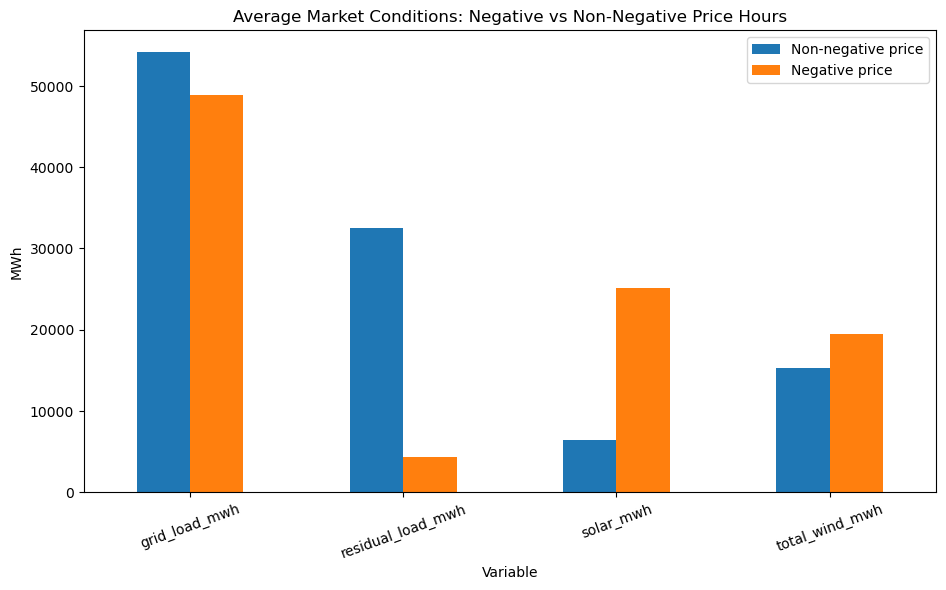

In [63]:
comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Average Market Conditions: "
    "Negative vs Non-Negative Price Hours"
)
plt.xlabel("Variable")
plt.ylabel("MWh")
plt.xticks(rotation=20)
plt.legend([
    "Non-negative price",
    "Negative price"
])
plt.show()

### Residual-load deciles
`pd.qcut()` divides residual load into ten groups containing roughly equal numbers of observations.

Decile 1 contains the lowest residual-load observations and decile 10 the highest. Price statistics are then calculated for each group.

**Why deciles instead of a single correlation only?** Dividing residual load into ten similarly sized groups reveals how average price changes across the full range of residual load. This can expose a nonlinear relationship that one correlation coefficient may hide.


In [64]:
market["residual_load_decile"] = (
    pd.qcut(
        market["residual_load_mwh"],
        10,
        labels=False,
        duplicates="drop"
    ) + 1
)

In [65]:
residual_decile_prices = (
    market.groupby(
        "residual_load_decile"
    )["price_eur_mwh"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .round(2)
)

In [66]:
residual_decile_prices

,mean,median,min,max
residual_load_decile,,,,
1,8.85,0.96,-500.00,249.58
2,53.94,55.02,-6.03,336.20
3,84.79,77.88,-0.09,467.45
4,105.41,88.32,0.03,585.03
5,123.48,97.12,13.04,590.85
6,143.51,105.04,51.80,704.62
7,150.85,112.01,55.12,750.03
8,166.16,124.80,58.19,781.62
9,187.10,139.37,60.36,855.46


### Plot average price by residual-load decile
This shows whether electricity prices tend to increase as residual load rises.

**Why plot the decile means?** The plot makes it easier to see whether price generally rises as residual load moves from low to high conditions and whether that relationship appears smooth or concentrated in certain ranges.


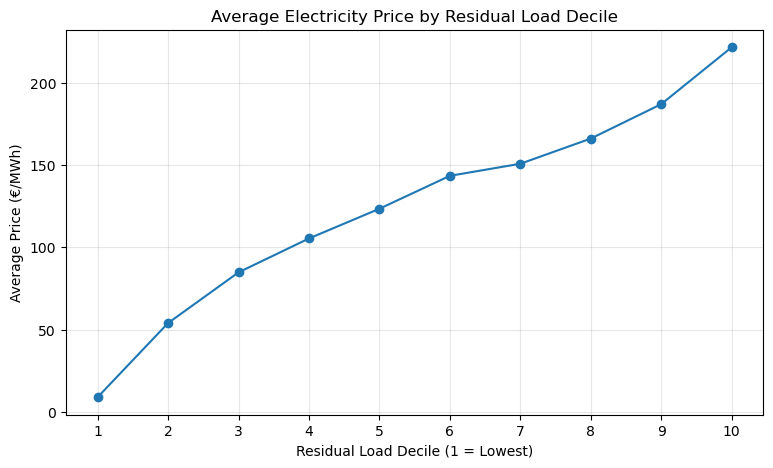

In [67]:
plt.figure(figsize=(9, 5))
plt.plot(
    residual_decile_prices.index,
    residual_decile_prices["mean"],
    marker="o"
)
plt.title(
    "Average Electricity Price by Residual Load Decile"
)
plt.xlabel("Residual Load Decile (1 = Lowest)")
plt.ylabel("Average Price (€/MWh)")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

### Correlation with electricity price
Correlation measures linear association from `-1` to `+1`. Positive values mean two variables tend to move together; negative values mean they tend to move in opposite directions.

Correlation does **not** prove causation.

**Why calculate correlation?** Correlation gives a compact first measure of the direction and strength of linear association between price and each market variable. It is used here for exploration, not as proof of causality, and it does not capture all nonlinear relationships.


In [68]:
correlations = (
    market[
        [
            "price_eur_mwh",
            "grid_load_mwh",
            "residual_load_mwh",
            "solar_mwh",
            "total_wind_mwh",
            "wind_solar_mwh"
        ]
    ]
    .corr()["price_eur_mwh"]
    .sort_values()
)

correlations

wind_solar_mwh      -0.455836
total_wind_mwh      -0.348997
solar_mwh           -0.204288
grid_load_mwh        0.206653
residual_load_mwh    0.581135
price_eur_mwh        1.000000
Name: price_eur_mwh, dtype: float64

### EDA findings

Negative-price hours were associated with substantially different system conditions:

- Average residual load was about **86.9% lower** than during non-negative-price hours.
- Average solar generation was about **293.9% higher**.
- Average total wind generation was about **27.6% higher**.
- Average wind + solar generation was about **106.0% higher**.

Across all observations, residual load had the strongest positive linear correlation with price (`r ≈ 0.58`), while combined wind and solar generation was negatively correlated with price (`r ≈ -0.46`).

These results describe **association, not causation**.

## 6. Feature engineering for 24-hour-ahead forecasting

The goal is to predict the electricity price **24 hours ahead** using information from earlier hours.

Calendar variables such as hour, weekday and month are known in advance. Price, load and renewable variables are shifted back so that the model does not use information from inside the forecast horizon.

A 24-hour horizon is useful for studying day-ahead price behaviour and connects naturally with the later battery simulation.

> **Project scope:** this is a rolling 24-hour-ahead forecasting experiment. It does not recreate the exact operational timing of the German day-ahead auction or the publication timing of every market input. That is a deliberate simplification for this learning project.


### Sort chronologically and add calendar features
Lag calculations depend on row order, so the market data is sorted by UTC first.

The target hour, weekday and month are known in advance and can therefore be used safely as forecasting features.

**Why sort first?** `shift()` works by row position. Chronological sorting guarantees that “24 rows earlier” really means 24 hours earlier.

**Why calendar features?** Hour, weekday and month are known in advance and capture recurring demand, solar and behavioural patterns without leaking future prices.


In [69]:
model = (market.sort_values("timestamp_utc").reset_index(drop=True).copy())

In [70]:
model["target_hour"] = (model["timestamp_berlin"].dt.hour)

In [71]:
model["target_day_of_week"] = (model["timestamp_berlin"].dt.dayofweek)

In [72]:
model["target_month"] = (model["timestamp_berlin"].dt.month)

### Historical price lags

We use prices from 24, 48 and 168 hours earlier.

- `24h` captures the previous day's price pattern.
- `48h` gives another recent daily reference.
- `168h` captures the weekly pattern.

These are simple, domain-based lag choices rather than values produced by an optimisation procedure.


In [73]:
model["price_lag_24h"] = (model["price_eur_mwh"].shift(24))

In [74]:
model["price_lag_48h"] = (model["price_eur_mwh"].shift(48))

In [75]:
model["price_lag_168h"] = (model["price_eur_mwh"].shift(168))

### Historical system lags

The model also uses historical load, residual load, wind and solar information.

The 24-hour lags describe market conditions one day earlier, while the 168-hour residual-load lag gives a weekly reference.

These variables are useful because electricity prices depend not only on previous prices but also on the balance between demand and renewable generation.

> **Modelling assumption:** the lagged SMARD system values are treated as historical information available to the model. This notebook does not reconstruct the exact publication timestamp of every realised measurement.


In [76]:
model["residual_load_lag_24h"] = (model["residual_load_mwh"].shift(24))

In [77]:
model["residual_load_lag_168h"] = (model["residual_load_mwh"].shift(168))

In [78]:
model["grid_load_lag_24h"] = (model["grid_load_mwh"].shift(24))

In [79]:
model["solar_lag_24h"] = (model["solar_mwh"].shift(24))

In [80]:
model["wind_lag_24h"] = (model["total_wind_mwh"].shift(24))

### Rolling historical price features
The price is shifted **before** calculating the rolling windows. This is important because it prevents the rolling statistics from seeing prices inside the 24-hour forecast horizon.

**Why rolling mean and standard deviation?** A single lag describes one historical hour, while rolling features summarise the recent price regime. The mean captures the local price level and the standard deviation captures recent volatility. Shifting first ensures the rolling window contains only information available before the forecast cutoff.


In [81]:
shifted_price = (model["price_eur_mwh"].shift(24))

In [82]:
model["price_mean_last_24h"] = (shifted_price.rolling(24).mean())

In [83]:
model["price_std_last_24h"] = (shifted_price.rolling(24).std())

In [84]:
model["price_mean_last_7d"] = (
    shifted_price.rolling(168).mean()
)

### Define the model features and build the modelling table

The feature list combines three types of information:

- **calendar structure** — hour, weekday and month;
- **historical prices** — daily/weekly lags and rolling statistics;
- **historical market conditions** — load, renewable generation and residual load.

This is intentionally a compact student feature set rather than an exhaustive search.

Residual load overlaps with some information already contained in load, wind and solar. It is kept because it is an important market-balance indicator, but testing a reduced feature set would be a useful future improvement.

Lagging and rolling create missing values at the beginning of the series, so those incomplete rows are removed before modelling.


In [85]:
features = [
    "target_hour",
    "target_day_of_week",
    "target_month",
    "price_lag_24h",
    "price_lag_48h",
    "price_lag_168h",
    "residual_load_lag_24h",
    "residual_load_lag_168h",
    "grid_load_lag_24h",
    "solar_lag_24h",
    "wind_lag_24h",
    "price_mean_last_24h",
    "price_std_last_24h",
    "price_mean_last_7d"
]

target = "price_eur_mwh"

### Build the clean modelling table
Only timestamps, the target and the selected features are kept. Rows made incomplete by lagging or rolling calculations are removed.

**Why drop incomplete rows?** Lags and rolling windows naturally create missing values at the beginning of the series. Those rows cannot provide the full predictor set, so they are removed rather than filled with invented historical values.


In [86]:
model_data = (
    model[
        [
            "timestamp_berlin",
            "timestamp_utc",
            target
        ] + features
    ]
    .dropna()
    .copy()
)

model_data.shape

(34873, 17)

## 7. Chronological train, validation and test split

A random split is avoided because this is time-series forecasting. The model should learn from earlier periods and be evaluated on later periods.

- **2022–2023:** training
- **2024:** validation and model comparison
- **2025:** final held-out test period

The 2025 market data was visible in the earlier descriptive EDA, but it is **not used to fit the models or choose the best model**. This distinction is more accurate than calling 2025 completely "untouched".


In [87]:
train = model_data[
    model_data["timestamp_berlin"].dt.year <= 2023
].copy()

In [88]:
validation = model_data[
    model_data["timestamp_berlin"].dt.year == 2024
].copy()

In [89]:
test = model_data[
    model_data["timestamp_berlin"].dt.year == 2025
].copy()

In [90]:
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Training: (17329, 17)
Validation: (8784, 17)
Test: (8760, 17)


## 8. Model development

The 24-hour persistence forecast is the main benchmark: it assumes the target-hour price will be the same as the price at the same hour one day earlier.

**Why compare several model types?** The models increase in flexibility: persistence is a market-specific naive benchmark, Linear Regression tests whether relationships are mostly linear, Random Forest captures nonlinear interactions through many independent trees, and XGBoost uses sequential boosted trees to model more complex patterns.


### Import modelling tools

MAE and RMSE are used to evaluate prediction error.

- **MAE** gives the average absolute error directly in €/MWh.
- **RMSE** penalises large forecasting misses more strongly.

MAPE is not used because electricity prices can be close to zero or negative, which makes percentage errors difficult to interpret.

The project compares persistence, Linear Regression, Random Forest and XGBoost so that a simple baseline and increasingly flexible models can be judged on the same data.


In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

### Evaluate the 24-hour persistence benchmark
MAE is the average absolute error. RMSE gives more weight to larger errors.

**Why persistence is the main benchmark?** Electricity prices have strong daily repetition, so using the price 24 hours earlier is a meaningful and surprisingly difficult baseline. A complex model should only be considered useful if it improves on this simple forecast.


In [92]:
validation["baseline_24h"] = (validation["price_lag_24h"])

In [93]:
baseline_mae = mean_absolute_error( validation["price_eur_mwh"], validation["baseline_24h"])

In [94]:
baseline_rmse = np.sqrt(mean_squared_error(validation["price_eur_mwh"], validation["baseline_24h"]))

In [95]:
print(
    f"24h persistence MAE:  "
    f"{baseline_mae:.2f} €/MWh"
)
print(
    f"24h persistence RMSE: "
    f"{baseline_rmse:.2f} €/MWh"
)

24h persistence MAE:  27.82 €/MWh
24h persistence RMSE: 44.30 €/MWh


### Prepare training and validation matrices
`X` contains the predictors and `y` contains the price target.

Hour, weekday and month are treated as categorical variables using one-hot encoding. The validation columns are reindexed to exactly match the training columns.

**Why separate `X` and `y`?** Machine-learning libraries expect predictors and target separately. Calendar variables are marked categorical because hour 23 is not numerically “23 times” hour 1; each category represents a distinct recurring market period.


In [96]:
X_train = train[features].copy()
y_train = train[target].copy()

In [97]:
X_val = validation[features].copy()
y_val = validation[target].copy()

In [98]:
categorical_features = [
    "target_hour",
    "target_day_of_week",
    "target_month"
]

### One-hot encode the calendar categories
The training set defines the final dummy-column structure. The validation set is then aligned to exactly the same columns.

**Why one-hot encoding?** It converts categorical calendar values into binary indicator columns so Linear Regression and the tree models can use them without incorrectly assuming a linear numerical distance between categories. Aligning validation columns prevents category mismatches between periods.


In [99]:
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)

In [100]:
X_val = pd.get_dummies(X_val, columns=categorical_features, drop_first=True)

In [101]:
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

### Linear Regression
This provides a simple linear reference model before moving to more flexible tree-based methods.

**Why Linear Regression?** It is intentionally simple and highly interpretable. If a more complex model cannot clearly outperform it, the extra complexity may not be justified.


In [102]:
linear_model = LinearRegression()

In [103]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [104]:
linear_predictions = (linear_model.predict(X_val))

In [105]:
linear_mae = mean_absolute_error(y_val,linear_predictions)

In [106]:
linear_rmse = np.sqrt(mean_squared_error(y_val,linear_predictions))

### Random Forest

Random Forest combines many decision trees and can capture nonlinear relationships between historical prices, calendar effects and system conditions.

The depth and leaf-size limits help control overfitting, while `random_state=42` makes the result reproducible.

The parameter values used here are reasonable manual settings for model comparison; they are not presented as fully optimised hyperparameters.


In [107]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [108]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [109]:
rf_predictions = (rf_model.predict(X_val))

In [110]:
rf_mae = mean_absolute_error(y_val, rf_predictions)

In [111]:
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_predictions))

### XGBoost

XGBoost builds trees sequentially so that later trees focus on errors made by earlier trees. This makes it useful for nonlinear tabular data such as electricity-market features.

The learning rate, tree depth and subsampling settings control model complexity. The values used here are manual modelling choices for this project, not the result of a full hyperparameter search.


In [112]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

### Train and evaluate XGBoost
The fitted model predicts the 2024 validation period, after which MAE and RMSE are calculated.

**Why evaluate on 2024 rather than training performance?** Training error mainly shows how well the model fits data it has already seen. The 2024 validation period provides a forward-looking check on unseen data and is therefore used for model selection.


In [113]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [114]:
xgb_predictions = (xgb_model.predict(X_val))

In [115]:
xgb_mae = mean_absolute_error(y_val, xgb_predictions)

In [116]:
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_predictions))

### Compare validation performance
The percentage-improvement column shows how much each model reduces MAE relative to the 24-hour persistence benchmark.

**Why compare every model in one table?** A common table ensures all methods are judged on the same validation period and metrics. This makes the trade-off between model complexity and forecasting improvement transparent.


In [117]:
model_results = pd.DataFrame({
    "Model": [
        "24h Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

### Add improvement relative to the baseline
A positive value means the model achieved a lower MAE than 24-hour persistence.

**Why report improvement versus baseline?** Absolute MAE is useful, but percentage improvement answers a more practical question: *how much forecasting error did the model remove compared with simply using yesterday's price?*


In [118]:
model_results[
    "MAE improvement vs baseline (%)"
] = (
    (
        baseline_mae
        - model_results["MAE"]
    )
    / baseline_mae
    * 100
)

model_results.round(2)

,Model,MAE,RMSE,MAE improvement vs baseline (%)
0,24h Persistence,27.82,44.30,0.00
1,Linear Regression,26.11,39.29,6.13
2,Random Forest,26.28,41.68,5.53
3,XGBoost,25.20,38.46,9.42


### XGBoost feature importance

Feature importance gives a simple view of which predictors the fitted XGBoost model used most strongly.

This is useful for interpretation, but it should not be read as proof of causation. Correlated predictors can also share or redistribute importance.


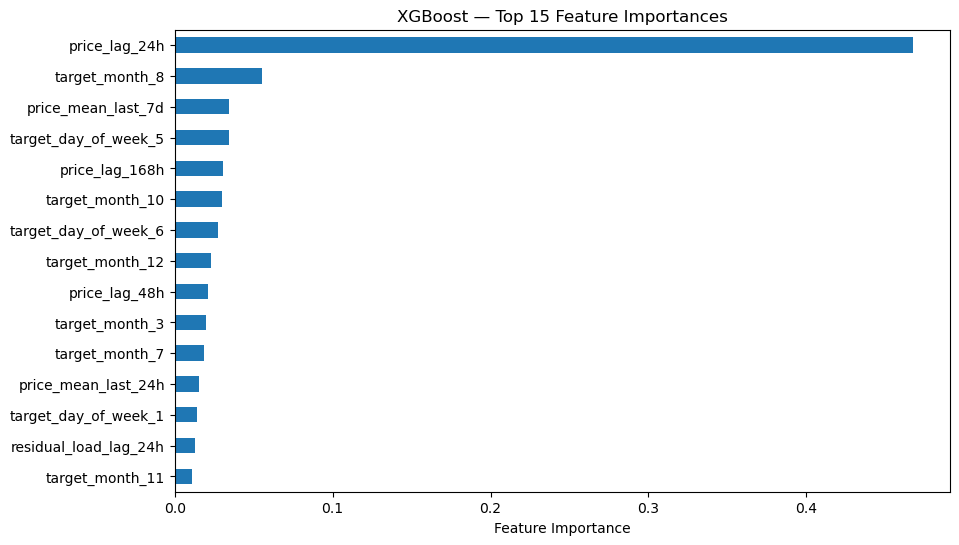

In [119]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

xgb_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "XGBoost — Top 15 Feature Importances"
)
plt.xlabel("Feature Importance")
plt.show()

### Validation result

XGBoost produced the lowest validation error:

- **MAE:** 25.20 €/MWh
- **RMSE:** 38.46 €/MWh
- **MAE improvement over 24h persistence:** 9.42%

XGBoost was therefore selected for the final 2025 evaluation.

**Why select XGBoost?** Model selection is based on validation performance, not on the later 2025 test result. In this notebook XGBoost has the lowest validation MAE and RMSE, so it is carried forward to the 2025 test. The 2025 observations are not used for model fitting or model selection.


## 9. Final out-of-sample evaluation on 2025

After choosing the model using the 2024 validation period, the 2022–2024 development data is combined and XGBoost is retrained.

The final model is then evaluated on 2025, which was not used for model fitting or model selection.

This gives a forward-looking test of whether the selected model continues to outperform the persistence benchmark in a later year.


### Prepare the combined development data
At this stage the 2024 validation set can be reused because model selection has already been completed.

**Why combine 2022–2024 now?** Once the model choice is fixed, the validation year no longer needs to remain separate. Adding it back gives the final XGBoost model more historical observations before forecasting 2025.


In [120]:
dev = pd.concat([train, validation], ignore_index=True)

In [121]:
X_dev = dev[features].copy()
y_dev = dev[target].copy()

In [122]:
X_test = test[features].copy()
y_test = test[target].copy()

### Encode the final development and test matrices
The same one-hot encoding procedure is repeated and the test columns are aligned to the development columns.

**Why repeat the same encoding?** The final model must receive predictors in exactly the same format used during development. Aligning test columns to the development matrix also prevents errors when a categorical level is absent or newly appears in one period.


In [123]:
X_dev = pd.get_dummies(X_dev, columns=categorical_features, drop_first=True)

In [124]:
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

In [125]:
X_test = X_test.reindex(columns=X_dev.columns, fill_value=0)

### Retrain XGBoost and predict 2025
The hyperparameters are kept unchanged from model development. No 2025 result is used to tune the model.

**Why keep the hyperparameters unchanged?** Changing them after seeing 2025 results would turn the test set into another validation set. Freezing the settings preserves the independence of the final evaluation.


In [126]:
final_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [127]:
final_xgb.fit(X_dev, y_dev)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [128]:
test_predictions = (
    final_xgb.predict(X_test)
)

### Calculate XGBoost and persistence errors on 2025
Both approaches are evaluated on exactly the same held-out 2025 test period.

**Why use both MAE and RMSE again?** The final result should be comparable with validation. MAE shows the average absolute €/MWh miss, while RMSE highlights whether the model still makes some very large errors.


In [129]:
test_mae = mean_absolute_error(y_test, test_predictions)

In [130]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

### Evaluate the 2025 persistence benchmark
The baseline is calculated separately so its error can be compared directly with XGBoost.

**Why re-evaluate persistence on 2025?** Baseline difficulty can change from year to year. Comparing XGBoost with the same baseline on exactly the same 2025 hours shows whether the improvement survives out of sample.


In [131]:
test_baseline_mae = mean_absolute_error(y_test, test["price_lag_24h"])

In [132]:
test_baseline_rmse = np.sqrt(mean_squared_error(y_test, test["price_lag_24h"]))

In [133]:
test_improvement = ((test_baseline_mae - test_mae) / test_baseline_mae * 100)

### Display the final comparison

Both XGBoost and the persistence benchmark are evaluated on the same 2025 hours, making the comparison directly comparable.


In [134]:
final_results = pd.DataFrame({
    "Model": [
        "2025 Persistence",
        "2025 XGBoost"
    ],
    "MAE": [
        test_baseline_mae,
        test_mae
    ],
    "RMSE": [
        test_baseline_rmse,
        test_rmse
    ]
})

In [135]:
display(final_results.round(2))
print("Final MAE improvement vs baseline:", f"{test_improvement:.2f}%")

,Model,MAE,RMSE
0,2025 Persistence,25.97,40.45
1,2025 XGBoost,22.61,33.81


Final MAE improvement vs baseline: 12.93%


### Final forecasting result

On the held-out 2025 test period:

- **24h persistence:** MAE 25.97 €/MWh, RMSE 40.45 €/MWh
- **XGBoost:** MAE 22.61 €/MWh, RMSE 33.81 €/MWh
- **MAE improvement:** 12.93%

The out-of-sample result indicates that the engineered historical and calendar features added predictive information beyond simply using the previous day's price.

### Visual check: actual vs predicted prices

Metrics summarise overall performance, but a short time-series plot makes it easier to see where the model follows the market and where it misses sharp movements.

The first two weeks of the 2025 test period are shown only as a visual diagnostic; model selection is still based on the validation metrics above.


In [136]:
forecast_check = test[
    ["timestamp_berlin", "price_eur_mwh"]
].copy()

forecast_check["predicted_price"] = test_predictions


In [137]:
forecast_sample = forecast_check.head(24 * 14)


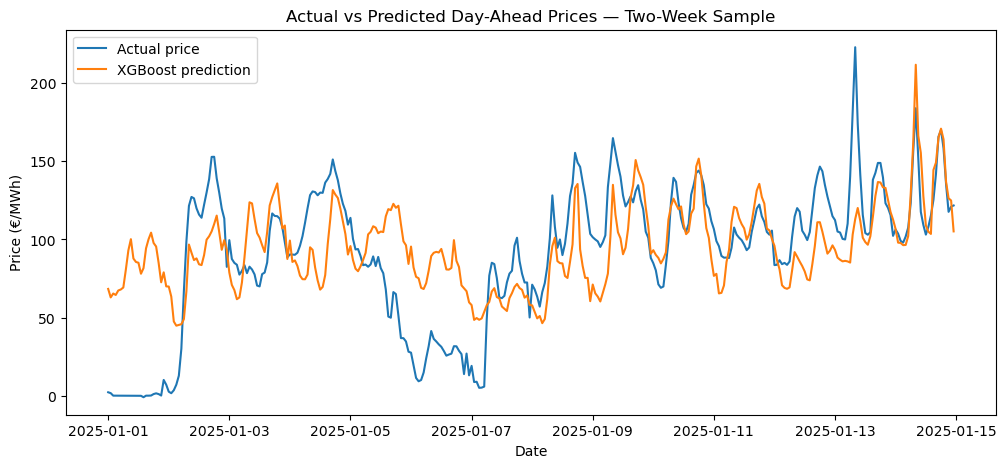

In [138]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_sample["timestamp_berlin"],
    forecast_sample["price_eur_mwh"],
    label="Actual price"
)

plt.plot(
    forecast_sample["timestamp_berlin"],
    forecast_sample["predicted_price"],
    label="XGBoost prediction"
)

plt.title("Actual vs Predicted Day-Ahead Prices — Two-Week Sample")
plt.xlabel("Date")
plt.ylabel("Price (€/MWh)")
plt.legend()
plt.show()


## 10. Simplified BESS arbitrage simulation

The forecasting model is now connected to a simple economic use case.

For each day in 2025, the strategy searches for **one charge hour and one later discharge hour**. It trades only when the signal suggests a positive spread after battery efficiency losses.

Three signals are compared:

1. **24h persistence** — uses the price 24 hours earlier as the signal;
2. **XGBoost forecast** — uses the model prediction;
3. **Actual-price reference** — uses the realised price itself and therefore represents the best one-cycle daily trade available under this simplified setup.

The realised P&L of every strategy is calculated using the actual market prices.

This is a learning simulation, not a production battery-optimisation model.


### Prepare the BESS test data

The 2025 actual prices, XGBoost predictions and persistence signal are placed in the same table.

A 5 MWh trade size and 90% round-trip efficiency are used to keep the example concrete while still accounting for storage losses.


In [139]:
bess_test = test[
    [
        "timestamp_berlin",
        "price_eur_mwh",
        "price_lag_24h"
    ]
].copy()


In [140]:
bess_test["predicted_price"] = test_predictions


In [141]:
bess_test["date"] = bess_test["timestamp_berlin"].dt.date


In [142]:
energy = 5
efficiency = 0.90


### Select the best charge-discharge pair for a signal

Instead of simply choosing the cheapest hour first, the function checks every valid **charge-before-discharge** pair within the day.

This avoids missing a better trade where a slightly more expensive early charge is followed by a much higher later selling price.

If no pair has positive expected P&L after efficiency losses, the strategy does not trade that day.


In [143]:
def select_best_trade(day, signal_col):
    best_charge = None
    best_discharge = None
    best_signal_pnl = 0.0

    for charge in range(len(day) - 1):
        for discharge in range(charge + 1, len(day)):
            buy_signal = day.loc[charge, signal_col]
            sell_signal = day.loc[discharge, signal_col]

            signal_pnl = (
                sell_signal * energy * efficiency
                - buy_signal * energy
            )

            if signal_pnl > best_signal_pnl:
                best_signal_pnl = signal_pnl
                best_charge = charge
                best_discharge = discharge

    return best_charge, best_discharge


### Calculate realised P&L

The signal chooses the trading hours, but the profit calculation uses the **actual** electricity prices.

If the strategy decides not to trade, daily P&L is zero.


In [144]:
def calculate_realised_pnl(day, charge, discharge):
    if charge is None:
        return 0.0

    buy_price = day.loc[charge, "price_eur_mwh"]
    sell_price = day.loc[discharge, "price_eur_mwh"]

    return (
        sell_price * energy * efficiency
        - buy_price * energy
    )


### Simulate one strategy across all days

The same mechanics are reused for each signal so that persistence, XGBoost and the actual-price reference are compared fairly.


In [145]:
def simulate_daily_strategy(data, signal_col, pnl_name):
    results = []

    for date, day in data.groupby("date"):
        day = day.reset_index(drop=True)

        charge, discharge = select_best_trade(
            day,
            signal_col
        )

        pnl = calculate_realised_pnl(
            day,
            charge,
            discharge
        )

        results.append([
            date,
            pnl,
            charge is not None
        ])

    return pd.DataFrame(
        results,
        columns=[
            "date",
            pnl_name,
            f"{pnl_name}_traded"
        ]
    )


### Run the three BESS strategies

Persistence gives the economic baseline, just as it did in the forecasting section.

The actual-price reference uses information that would not be known in advance. It is included only as an upper reference for this simplified one-cycle rule.


In [146]:
persistence_results = simulate_daily_strategy(
    bess_test,
    "price_lag_24h",
    "persistence_pnl_eur"
)


In [147]:
xgb_results = simulate_daily_strategy(
    bess_test,
    "predicted_price",
    "xgb_pnl_eur"
)


In [148]:
actual_reference_results = simulate_daily_strategy(
    bess_test,
    "price_eur_mwh",
    "actual_reference_pnl_eur"
)


In [149]:
daily_results = (
    persistence_results
    .merge(
        xgb_results,
        on="date",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        actual_reference_results,
        on="date",
        how="inner",
        validate="one_to_one"
    )
)


### Compare economic results

The important question is not only whether XGBoost has a lower MAE, but whether its forecasts also lead to better trading decisions than the simple persistence signal.


In [150]:
strategy_summary = pd.DataFrame({
    "Strategy": [
        "24h Persistence",
        "XGBoost Forecast",
        "Actual-Price Reference"
    ],
    "Total P&L (€)": [
        daily_results["persistence_pnl_eur"].sum(),
        daily_results["xgb_pnl_eur"].sum(),
        daily_results["actual_reference_pnl_eur"].sum()
    ],
    "Trading Days": [
        daily_results["persistence_pnl_eur_traded"].sum(),
        daily_results["xgb_pnl_eur_traded"].sum(),
        daily_results["actual_reference_pnl_eur_traded"].sum()
    ],
    "Loss-Making Days": [
        (daily_results["persistence_pnl_eur"] < 0).sum(),
        (daily_results["xgb_pnl_eur"] < 0).sum(),
        (daily_results["actual_reference_pnl_eur"] < 0).sum()
    ]
})

strategy_summary.round(2)


,Strategy,Total P&L (€),Trading Days,Loss-Making Days
0,24h Persistence,168013.28,365,8
1,XGBoost Forecast,173344.64,365,9
2,Actual-Price Reference,193534.72,365,0


In [151]:
xgb_vs_persistence = (
    daily_results["xgb_pnl_eur"].sum()
    - daily_results["persistence_pnl_eur"].sum()
)

print(
    "XGBoost P&L difference vs persistence:",
    round(xgb_vs_persistence, 2),
    "€"
)


XGBoost P&L difference vs persistence: 5331.37 €


### Plot cumulative simulated P&L

Cumulative P&L shows how the three strategies develop through the year rather than only comparing their final totals.


In [152]:
daily_results["persistence_cumulative"] = (
    daily_results["persistence_pnl_eur"].cumsum()
)

daily_results["xgb_cumulative"] = (
    daily_results["xgb_pnl_eur"].cumsum()
)

daily_results["actual_reference_cumulative"] = (
    daily_results["actual_reference_pnl_eur"].cumsum()
)


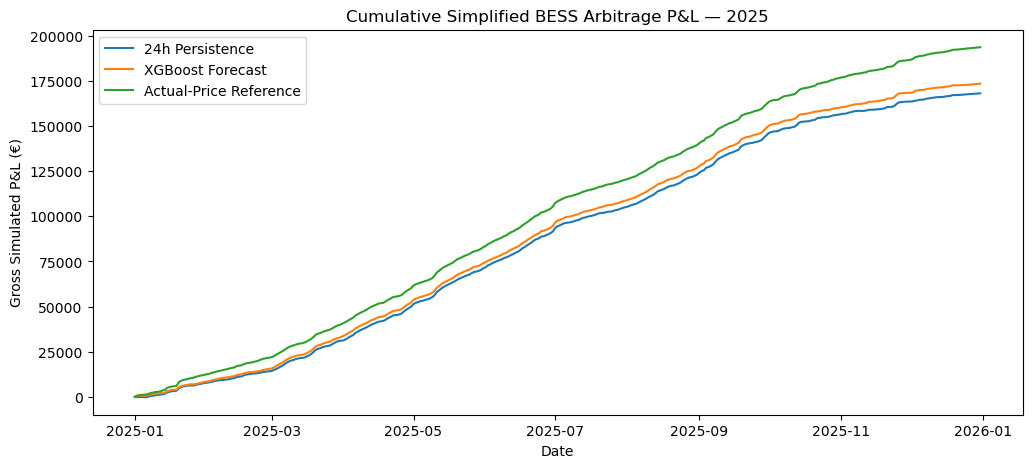

In [153]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_results["date"],
    daily_results["persistence_cumulative"],
    label="24h Persistence"
)

plt.plot(
    daily_results["date"],
    daily_results["xgb_cumulative"],
    label="XGBoost Forecast"
)

plt.plot(
    daily_results["date"],
    daily_results["actual_reference_cumulative"],
    label="Actual-Price Reference"
)

plt.title("Cumulative Simplified BESS Arbitrage P&L — 2025")
plt.xlabel("Date")
plt.ylabel("Gross Simulated P&L (€)")
plt.legend()
plt.show()


### Interpreting the BESS comparison

The persistence strategy is the economic baseline. In the simplified 2025 BESS simulation, the XGBoost signal produced total P&L of **€173,344.64**, compared with **€168,013.28** for persistence. This is an improvement of about **€5,331 (3.17%)** under the same trading rule.

XGBoost still produced **9 loss-making days**, compared with **8** for persistence. This shows that lower forecasting error does not guarantee a better trading decision every day, even when it improves the total simulated result.

The actual-price reference produced **€193,534.72** and shows the opportunity available when the day's prices are already known. It is **not** a realistic trading forecast and should not be interpreted as real battery revenue.

The simulation still excludes battery degradation, transaction costs, detailed state-of-charge constraints, power limits and market-execution effects.


## 11. Conclusion

This project connects electricity-market analysis, 24-hour-ahead forecasting and a simplified battery-arbitrage application.

The exploratory analysis found that negative-price periods were associated with high wind and solar generation and low residual load. Residual load also showed a strong relationship with day-ahead electricity prices in the analysed data.

For forecasting, XGBoost performed best among the tested models. On the 2025 test period it achieved an MAE of **22.61 €/MWh**, compared with **25.97 €/MWh** for 24-hour persistence, corresponding to a **12.93% MAE improvement**.

The final BESS section then asks a second question: does the better forecast also support better economic decisions than persistence? Persistence, XGBoost and an actual-price reference are therefore evaluated under the same simplified daily trading rule.

### Limitations and possible extensions

- The forecasting setup is a **rolling 24-hour-ahead experiment**, not an exact recreation of operational day-ahead auction timing.
- The exact publication time of every realised SMARD load and generation observation is not reconstructed.
- Hyperparameters were selected manually rather than through an extensive optimisation process.
- Residual load overlaps with information contained in load, wind and solar; a reduced feature set could be tested.
- The BESS model uses one daily cycle and simplified efficiency rather than full state-of-charge, power-limit and degradation modelling.
- Future work could use published day-ahead load/renewable forecasts and formal time-series cross-validation.

These limitations are kept explicit because the aim of the project is to demonstrate an end-to-end learning process rather than present a production trading system.
